EDA

In [13]:
import pandas as pd
import matplotlib.pyplot as plt # <--- Исправлено здесь
import seaborn as sns 

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

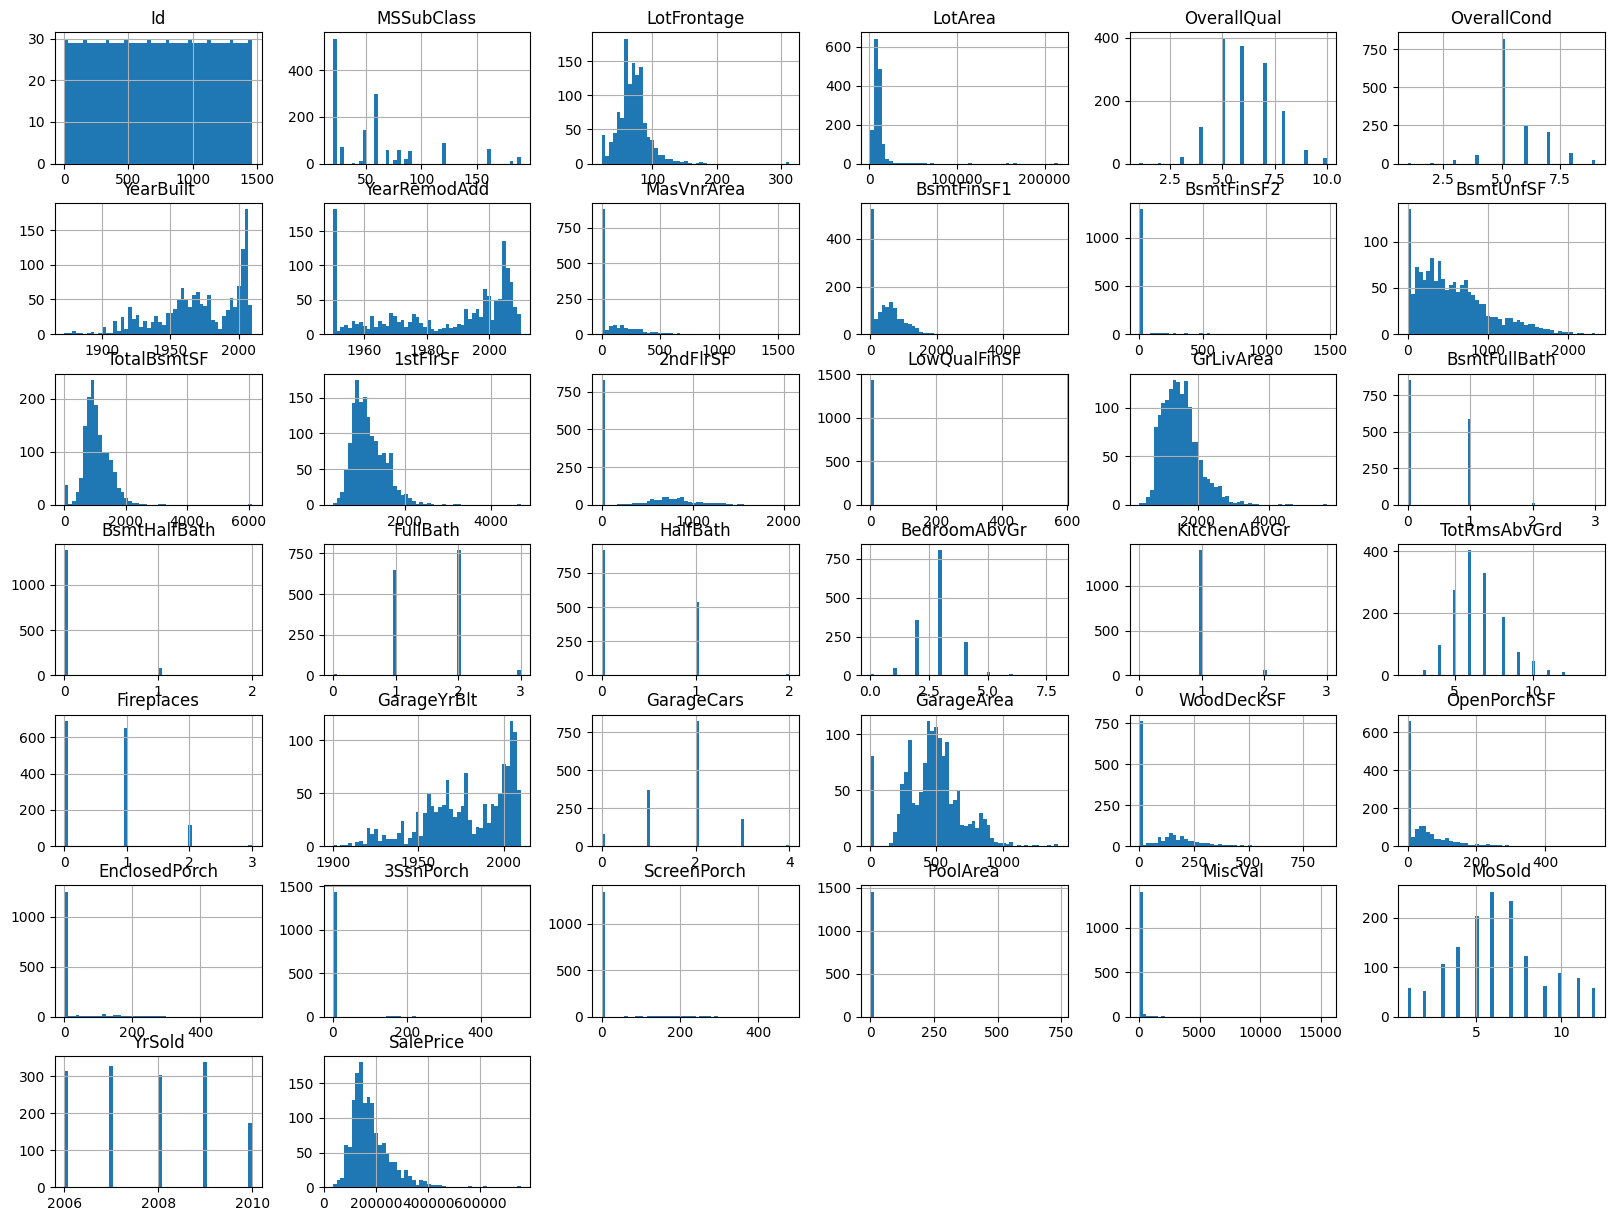

In [14]:
df = pd.read_csv('../data/train.csv')
df.hist(bins=50, figsize=(20,15))

In [15]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [16]:
df.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [17]:
# 1. Считаем корреляцию
corr_matrix = df.corr(numeric_only=True)

# 2. Разворачиваем матрицу в список пар (признак_1, признак_2)
corr_pairs = corr_matrix.unstack()

# 3. Убираем корреляции признаков самих с собой (где значение равно 1.0)
corr_pairs = corr_pairs[corr_pairs != 1.0]

# 4. Убираем дубликаты (т.к. корреляция A с B равна корреляции B с A)
# Для этого отсортируем индексы перед удалением дубликатов
corr_pairs = corr_pairs.loc[
    corr_pairs.index.map(lambda x: tuple(sorted(x))).drop_duplicates()
]

# 5. Сортируем по убыванию модуля корреляции (чтобы сильные отрицательные тоже были в топе)
sorted_pairs = corr_pairs.abs().sort_values(ascending=False)

# Выводим топ-15 самых сильных связей
print("Топ самых сильных корреляций между признаками:")
print(sorted_pairs.head(15))

Топ самых сильных корреляций между признаками:
GarageArea    GarageCars      0.882475
GarageYrBlt   YearBuilt       0.825667
GrLivArea     TotRmsAbvGrd    0.825489
1stFlrSF      TotalBsmtSF     0.819530
OverallQual   SalePrice       0.790982
GrLivArea     SalePrice       0.708624
2ndFlrSF      GrLivArea       0.687501
BedroomAbvGr  TotRmsAbvGrd    0.676620
BsmtFinSF1    BsmtFullBath    0.649212
GarageYrBlt   YearRemodAdd    0.642277
GarageCars    SalePrice       0.640409
FullBath      GrLivArea       0.630012
GarageArea    SalePrice       0.623431
2ndFlrSF      TotRmsAbvGrd    0.616423
SalePrice     TotalBsmtSF     0.613581
dtype: float64


In [18]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [27]:
df['OverallQual']

0       7
1       6
2       7
3       7
4       8
       ..
1455    6
1456    6
1457    7
1458    5
1459    5
Name: OverallQual, Length: 1460, dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(1460, 81)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [22]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [23]:
df.memory_usage()

Index              132
Id               11680
MSSubClass       11680
MSZoning         11680
LotFrontage      11680
                 ...  
MoSold           11680
YrSold           11680
SaleType         11680
SaleCondition    11680
SalePrice        11680
Length: 82, dtype: int64

In [24]:
for col in df.columns:
    print(f"Колонка {col} имеет {df[col].nunique()} уникальных значений")

Колонка Id имеет 1460 уникальных значений
Колонка MSSubClass имеет 15 уникальных значений
Колонка MSZoning имеет 5 уникальных значений
Колонка LotFrontage имеет 110 уникальных значений
Колонка LotArea имеет 1073 уникальных значений
Колонка Street имеет 2 уникальных значений
Колонка Alley имеет 2 уникальных значений
Колонка LotShape имеет 4 уникальных значений
Колонка LandContour имеет 4 уникальных значений
Колонка Utilities имеет 2 уникальных значений
Колонка LotConfig имеет 5 уникальных значений
Колонка LandSlope имеет 3 уникальных значений
Колонка Neighborhood имеет 25 уникальных значений
Колонка Condition1 имеет 9 уникальных значений
Колонка Condition2 имеет 8 уникальных значений
Колонка BldgType имеет 5 уникальных значений
Колонка HouseStyle имеет 8 уникальных значений
Колонка OverallQual имеет 10 уникальных значений
Колонка OverallCond имеет 9 уникальных значений
Колонка YearBuilt имеет 112 уникальных значений
Колонка YearRemodAdd имеет 61 уникальных значений
Колонка RoofStyle име

Graphics

C:\Temp\ipykernel_9872\3472876812.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


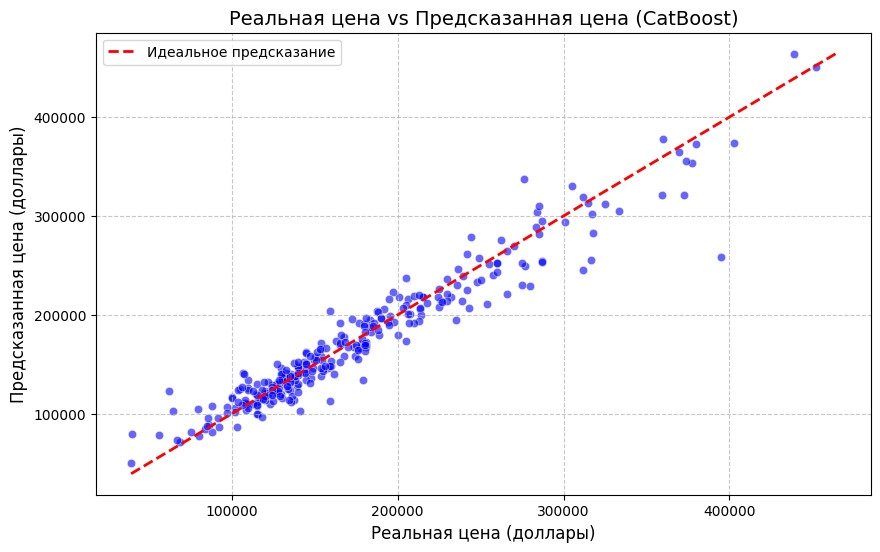

In [25]:
# Код для построения графика: Реальная цена vs Предсказанная цена (на основе актуального пайплайна)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import sys, os
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    os.chdir('..')
    sys.path.append(os.getcwd())

from main import load_data, split_data
from features import feature_engineering
from main import get_preprocessor
from main import get_models
from sklearn.pipeline import Pipeline

# 1. Готовим данные
X, y, _ = load_data()
X = feature_engineering(X)
y = np.log1p(y)
X_train, X_test, y_train, y_test_log = split_data(X, y)

# 2. Собираем пайплайн (например, для CatBoost)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns
preprocessor = get_preprocessor(numeric_features, categorical_features)
models = get_models()
model = models['CatBoost']

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# 3. Обучаем и предсказываем
pipeline.fit(X_train, y_train)
y_pred_log = pipeline.predict(X_test)

# Возвращаем цены в доллары для наглядности
y_test_dollars = np.expm1(y_test_log)
y_pred_dollars = np.expm1(y_pred_log)

# --- Построение графика ---
plt.figure(figsize=(10, 6))
# Рисуем точки (Реальная цена vs Предсказанная цена)
sns.scatterplot(x=y_test_dollars, y=y_pred_dollars, alpha=0.6, color='blue')

# Рисуем идеальную линию
min_val = min(y_test_dollars.min(), y_pred_dollars.min())
max_val = max(y_test_dollars.max(), y_pred_dollars.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Идеальное предсказание')

# Настраиваем отображение
plt.title('Реальная цена vs Предсказанная цена (CatBoost)', fontsize=14)
plt.xlabel('Реальная цена (доллары)', fontsize=12)
plt.ylabel('Предсказанная цена (доллары)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Возвращаем директорию обратно, если меняли
if os.path.basename(current_dir) == 'notebooks':
    os.chdir(current_dir)

C:\Temp\ipykernel_9872\2144617711.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns
C:\Temp\ipykernel_9872\2144617711.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


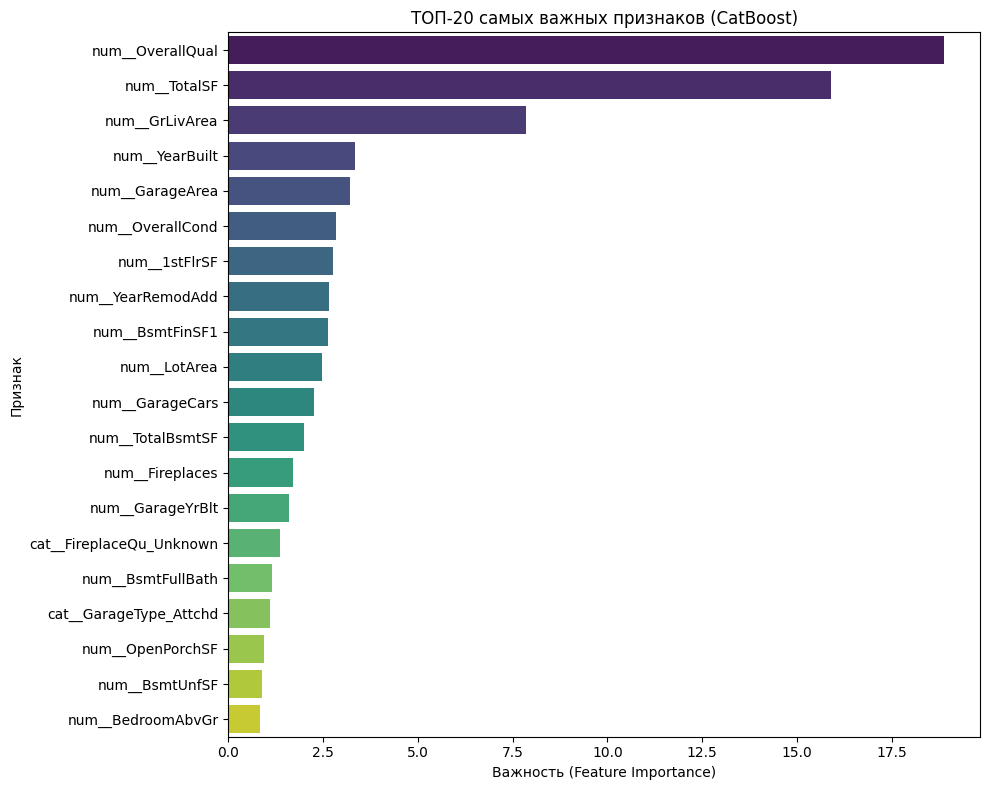

In [26]:
# Код для получения Feature Importances модели CatBoost
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем модули из проекта
import sys, os
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    os.chdir('..')
    sys.path.append(os.getcwd())

from main import load_data, split_data
from features import feature_engineering
from main import get_preprocessor
from main import get_models
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Загружаем и готовим данные
X, y, _ = load_data()
X = feature_engineering(X)
y = np.log1p(y)
X_train, _, y_train, _ = split_data(X, y)

# 2. Собираем препроцессор и модель CatBoost
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns
preprocessor = get_preprocessor(numeric_features, categorical_features)
models = get_models()
catboost_model = models['CatBoost']

# 3. Собираем и обучаем пайплайн
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', catboost_model)
])
pipeline.fit(X_train, y_train)

# 4. Достаем названия признаков после препроцессинга (OneHotEncoder)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 5. Достаем важность признаков из CatBoost
importances = pipeline.named_steps['model'].feature_importances_

# 6. Создаем DataFrame и сортируем
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 7. Рисуем ТОП-20 признаков
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(20),
    palette='viridis'
)
plt.title('ТОП-20 самых важных признаков (CatBoost)')
plt.xlabel('Важность (Feature Importance)')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# Возвращаем директорию обратно, если меняли
if os.path.basename(current_dir) == 'notebooks':
    os.chdir(current_dir)